# Function Approximation Using Orthogonal Projections 

In [1]:
from pathlib import Path
import numpy as np
from numpy import pi, sin, exp
from numpy.polynomial import Polynomial
from scipy import integrate
from typing import Callable
from functools import reduce

import matplotlib.pyplot as plt
plt.style.use('./math.mplstyle')

FIGURES_DIR = Path('../tex/figures/')

The target function we want to approximate:

In [2]:
target_func = lambda x: sin(x) * exp(x)

Construct polynomials using NumPy's `Polynomial` class:

In [3]:
Polynomial([1, 2, 3])

Polynomial([1., 2., 3.], domain=[-1,  1], window=[-1,  1], symbol='x')

Define inner product on the vector space:

In [4]:
def inner_product(func1: Callable, func2: Callable) -> float:
    
    # product of two functions
    product_func = lambda x: func1(x) * func2(x)
    
    # calculate integral on [-pi, pi]
    integral, abs_err = integrate.quad(product_func, a=-pi, b=pi)
    
    return integral

inner_product(lambda x: x, Polynomial((0, 1)))

20.670851120199877

In [5]:
def func_add(func1: Callable, func2: Callable) -> Callable:
    
    if isinstance(func1, Polynomial) and isinstance(func2, Polynomial):
        return func1 + func2
    else:
        return lambda x: func1(x) + func2(x)

def func_subtract(func1: Callable, func2: Callable) -> Callable:
    
    if isinstance(func1, Polynomial) and isinstance(func2, Polynomial):
        return func1 - func2
    else:
        return lambda x: func1(x) - func2(x)

In [6]:
def project_on_func(func: Callable, onto_func: Callable) -> Callable:
    
    # norm of the function to project on
    norm_of_onto_func=  inner_product(onto_func, onto_func)
    assert norm_of_onto_func != 0
    
    # scalar coefficient
    coef = inner_product(onto_func, func) / norm_of_onto_func
    
    # the projected function
    if isinstance(onto_func, Polynomial):
        projected_func = coef * onto_func
    else:
        projected_func = lambda x: coef * onto_func(x)
    
    return projected_func

def project_on_subspace(func: Callable, subspace: list[Callable]) -> Callable:
    
    return reduce(
        func_add,
        [
            project_on_func(func, onto_func)
            for onto_func in subspace
        ]
    )

project_on_subspace(lambda x: 2 * x, [Polynomial((0, 1)), Polynomial((0, 0, 1))])

Polynomial([0., 2.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [7]:
def find_orthonormal_basis_via_gram_schmidt(basis: list[Callable]) -> list[Callable]:
    
    orthonormal_basis: list[Callable] = []
    for func in basis:
        
        for ortho_func in orthonormal_basis:
            projected_func = project_on_func(func, ortho_func)
            func = func_subtract(func, projected_func)
        
        norm_of_func = inner_product(func, func)
        assert norm_of_func != 0
        
        if isinstance(func, Polynomial):
            new_ortho_func = func / norm_of_func
        else:
            new_ortho_func = lambda x: func(x) / norm_of_func
        
        orthonormal_basis.append(new_ortho_func)
    
    return orthonormal_basis

In [8]:
def approximate_using_polynomial(target_func: Callable, max_degree: int = 3) -> Polynomial:
    
    basis = []
    for degree in range(0, max_degree + 1):
        coef = [0 for _ in range(degree)] + [1]
        basis.append(Polynomial(coef))
        
    orthonormal_basis = find_orthonormal_basis_via_gram_schmidt(basis)
    
    approx_func = project_on_subspace(target_func, orthonormal_basis)
    
    return approx_func

## Approximate Target Function using Polynomial

## Plot the Result

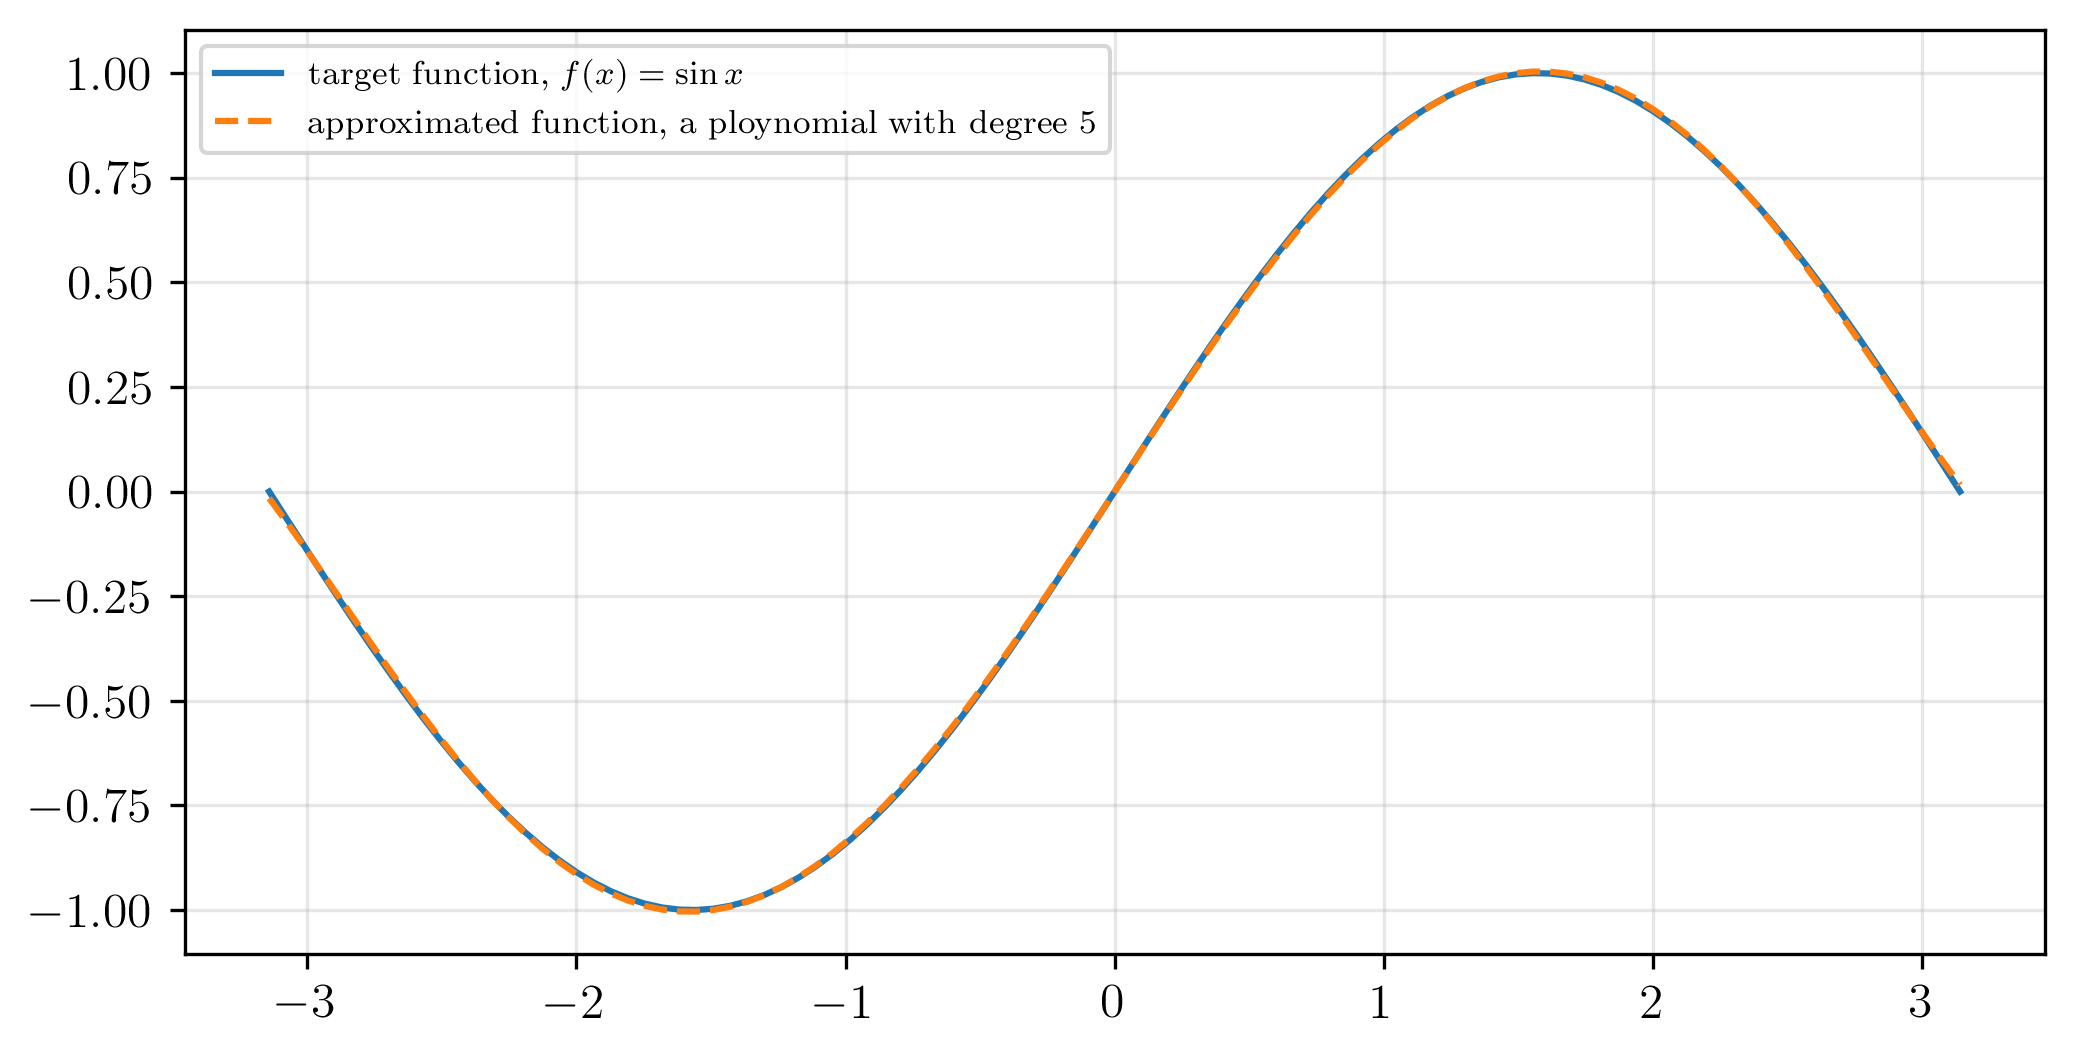

In [9]:
target_func = sin

approx_func = approximate_using_polynomial(
    target_func=target_func,
    max_degree=5
)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x = np.linspace(-pi, pi, 100)

ax.plot(
    x, target_func(x),
    label='target function, $f(x) = \sin x$'
)

ax.plot(
    x, approx_func(x),
    ls='--',
    label=f'approximated function, a ploynomial with degree ${approx_func.degree()}$',
)

ax.legend()

plt.savefig(
    FIGURES_DIR.joinpath('la-01').with_suffix('.png'),
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

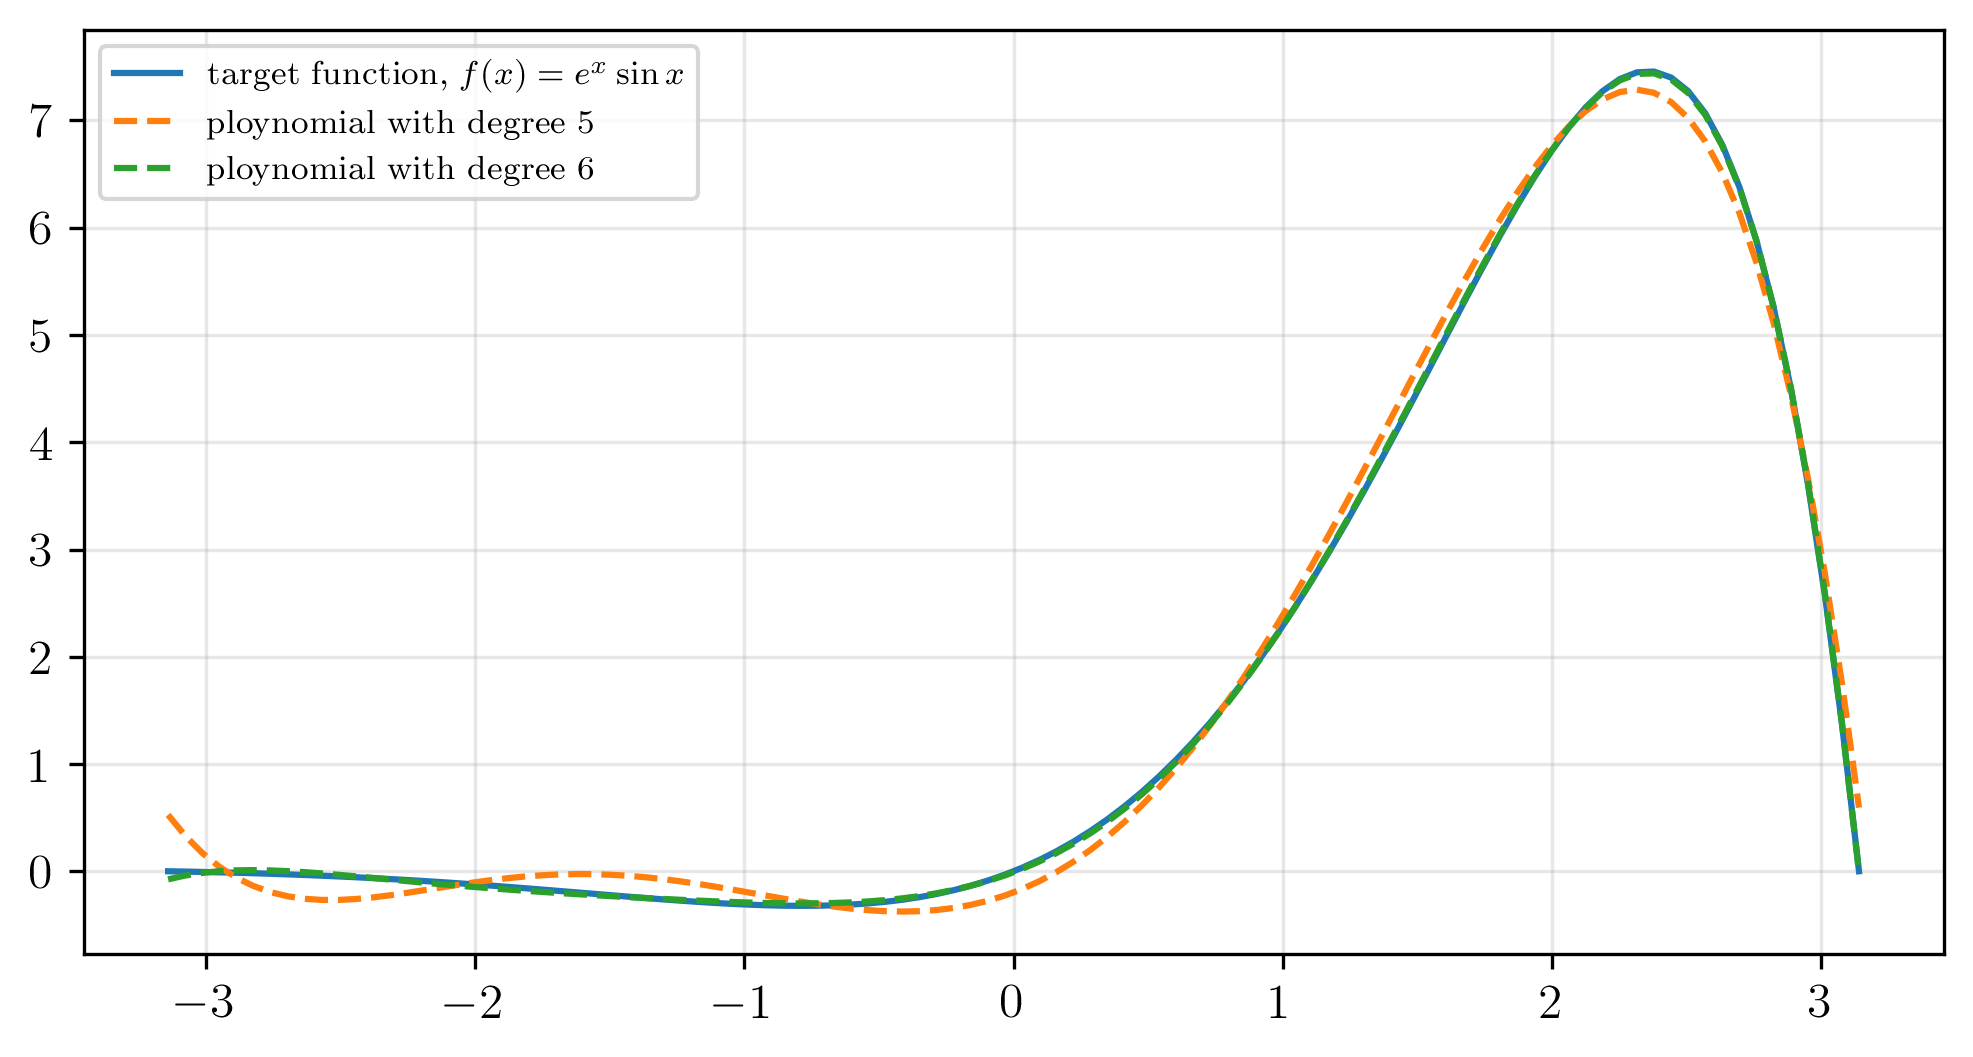

In [10]:
target_func = lambda x: sin(x) * exp(x)



fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x = np.linspace(-pi, pi, 100)

ax.plot(
    x, target_func(x),
    label='target function, $f(x) = e^x \sin x$'
)

approx_func = approximate_using_polynomial(
    target_func=target_func,
    max_degree=5
)

ax.plot(
    x, approx_func(x),
    ls='--',
    label=f'ploynomial with degree ${approx_func.degree()}$',
)

approx_func = approximate_using_polynomial(
    target_func=target_func,
    max_degree=6
)

ax.plot(
    x, approx_func(x),
    ls='--',
    label=f'ploynomial with degree ${approx_func.degree()}$',
)

ax.legend()

plt.savefig(
    FIGURES_DIR.joinpath('la-02').with_suffix('.png'),
    bbox_inches='tight',
    pad_inches=0
)

plt.show()